<a href="https://colab.research.google.com/github/adyasha95/Biomedical-ML-Pipeline/blob/main/code_geneticsbrc_classif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import requests
import json
import io

# --- STEP 1: Download Clinical Data ---
def get_tcga_clinical(project="TCGA-BRCA"):
    url = "https://api.gdc.cancer.gov/cases"
    filters = {
        "op": "and",
        "content": [{"op": "in", "content": {"field": "cases.project.project_id", "value": [project]}}]
    }
    params = {
        "filters": json.dumps(filters),
        "fields": "submitter_id,diagnoses.vital_status,diagnoses.tumor_stage,demographic.gender",
        "format": "JSON",
        "size": "1000"
    }
    response = requests.get(url, params=params)
    data = response.json()["data"]["hits"]
    # Flattening JSON to DataFrame
    df_clinical = pd.json_normalize(data)
    df_clinical.rename(columns={'submitter_id': 'Barcode'}, inplace=True)
    return df_clinical

# --- STEP 2: Download Gene Expression (Simplified for Demo) ---
# Note: In a real scenario, you'd download a manifest. Here we'll simulate
# the merge logic with the Barcode.
df_clin = get_tcga_clinical()
print(f"Clinical Samples found: {df_clin.shape[0]}")

Clinical Samples found: 1000


Running Nested CV...
Outer Fold 1 complete. Best C: 0.001 | Test BAC: 0.586
Outer Fold 2 complete. Best C: 1 | Test BAC: 0.600
Outer Fold 3 complete. Best C: 1 | Test BAC: 0.500
Outer Fold 4 complete. Best C: 0.001 | Test BAC: 0.500
Outer Fold 5 complete. Best C: 0.1 | Test BAC: 0.500


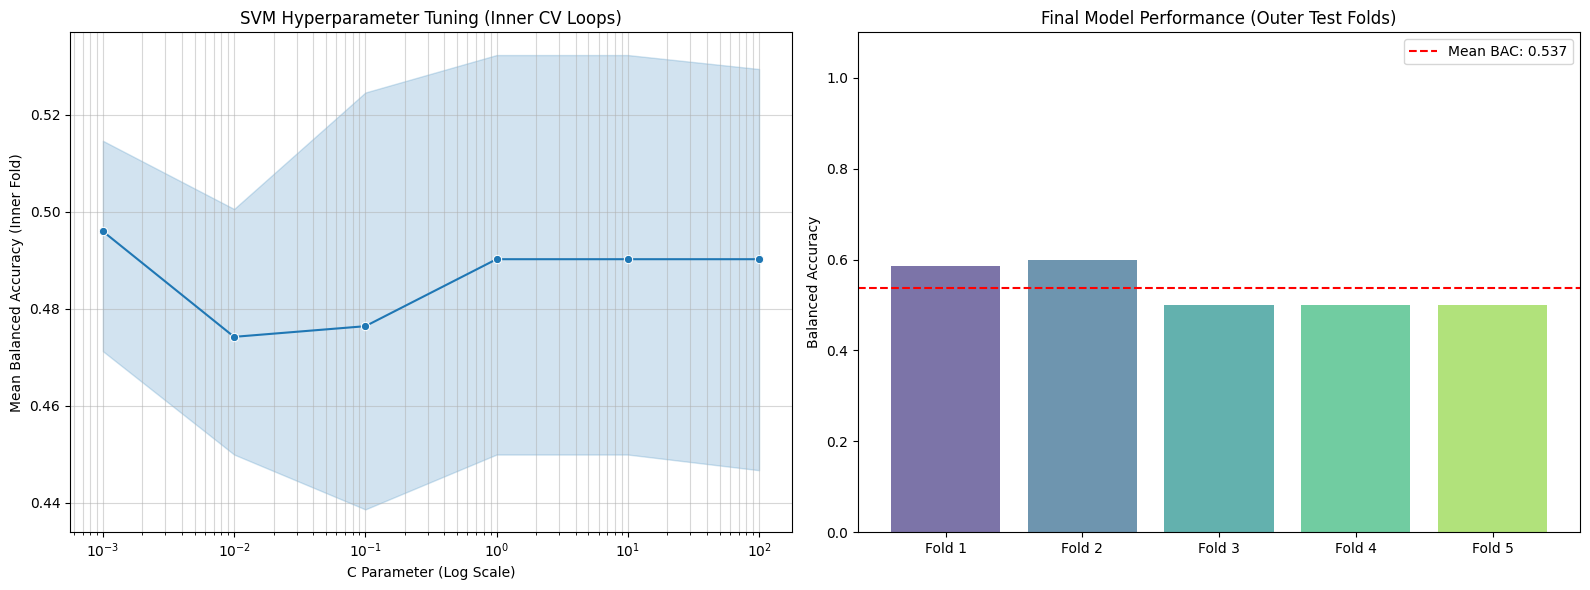


Summary: The final Nested CV Mean Balanced Accuracy is 0.5372


ValueError: All arrays must be of the same length

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, make_scorer

# 1. SETUP DATA (Assuming X and y are already defined from TCGA merge)
# If running fresh, ensure X and y are loaded.
# For demo, using synthetic genetic data:
if 'X' not in locals():
    X = pd.DataFrame(np.random.randn(200, 50))
    y = np.random.randint(0, 2, 200)

# 2. DEFINE THE NESTED CV STRUCTURE
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring
bac_scorer = make_scorer(balanced_accuracy_score)

# Define Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])

# Parameter range for C
param_grid = {'svm__C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Lists to store metrics for plotting
outer_bac_scores = []
inner_tuning_results = []

print("Running Nested CV...")

# 3. MANUAL OUTER LOOP TO CAPTURE TUNING DATA
for i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    X_train_out, X_test_out = X.iloc[train_idx], X.iloc[test_idx]
    y_train_out, y_test_out = y[train_idx], y[test_idx]

    # Inner Loop for Hyperparameter Tuning
    grid_search = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring=bac_scorer, n_jobs=-1)
    grid_search.fit(X_train_out, y_train_out)

    # Store inner tuning results for this outer fold
    res = pd.DataFrame(grid_search.cv_results_)
    res['outer_fold'] = i + 1
    inner_tuning_results.append(res)

    # Evaluate on Outer Test Set (The 'Unseen' Data)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_out)
    bac = balanced_accuracy_score(y_test_out, y_pred)
    outer_bac_scores.append(bac)

    print(f"Outer Fold {i+1} complete. Best C: {grid_search.best_params_['svm__C']} | Test BAC: {bac:.3f}")

# Aggregate Results
all_tuning_df = pd.concat(inner_tuning_results)
mean_outer_bac = np.mean(outer_bac_scores)

# --- VISUALIZATION ---

plt.figure(figsize=(16, 6))

# Plot 1: C Parameter Tuning vs Inner CV Performance
plt.subplot(1, 2, 1)
sns.lineplot(data=all_tuning_df, x='param_svm__C', y='mean_test_score', marker='o', err_style="band")
plt.xscale('log')
plt.title('SVM Hyperparameter Tuning (Inner CV Loops)')
plt.xlabel('C Parameter (Log Scale)')
plt.ylabel('Mean Balanced Accuracy (Inner Fold)')
plt.grid(True, which="both", ls="-", alpha=0.5)

# Plot 2: Balanced Accuracy (BAC) across Outer Test Folds
plt.subplot(1, 2, 2)
fold_labels = [f'Fold {i+1}' for i in range(len(outer_bac_scores))]
colors = sns.color_palette("viridis", len(outer_bac_scores))
plt.bar(fold_labels, outer_bac_scores, color=colors, alpha=0.7)
plt.axhline(mean_outer_bac, color='red', linestyle='--', label=f'Mean BAC: {mean_outer_bac:.3f}')
plt.ylim(0, 1.1)
plt.title('Final Model Performance (Outer Test Folds)')
plt.ylabel('Balanced Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nSummary: The final Nested CV Mean Balanced Accuracy is {mean_outer_bac:.4f}")

Starting Nested CV Pipeline...

--- Summary of Nested CV & C-Tuning ---
 Fold  Best_C  Outer_BAC
    1   0.100    0.40404
    2   0.001    0.50000
    3   0.001    0.50000
    4   0.001    0.50000
    5   1.000    0.60000


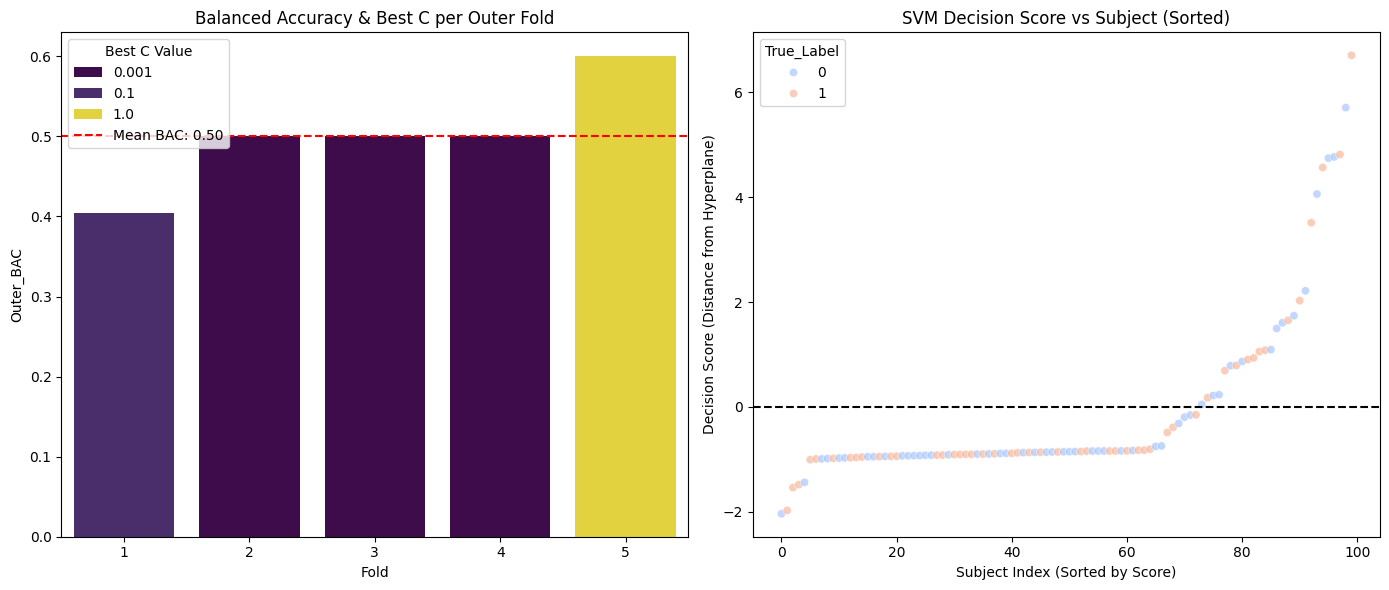

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score

# --- 1. SETUP ---
# (Assuming X and y from your TCGA merge are ready)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])

param_grid = {'svm__C': [0.001, 0.01, 0.1, 1, 10]}

# Storage for reporting
outer_results = []
all_decision_data = []

print("Starting Nested CV Pipeline...")

# --- 2. NESTED CV LOOP ---
for i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Split data for this outer fold
    X_train_out, X_test_out = X.iloc[train_idx], X.iloc[test_idx]
    y_train_out, y_test_out = y.iloc[train_idx], y.iloc[test_idx]

    # Inner Loop: Tuning C
    grid = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring='balanced_accuracy')
    grid.fit(X_train_out, y_train_out)

    # Evaluate Best Model on Outer Test Fold
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_out)
    bac = balanced_accuracy_score(y_test_out, y_pred)

    # Get Decision Scores for this fold
    scores = best_model.decision_function(X_test_out)

    # Store results for this fold
    outer_results.append({
        'Fold': i + 1,
        'Best_C': grid.best_params_['svm__C'],
        'Outer_BAC': bac
    })

    # Store Decision Score data for plotting (ensuring same lengths)
    fold_df = pd.DataFrame({
        'Decision_Score': scores,
        'True_Label': y_test_out.values,
        'Fold': i + 1
    })
    all_decision_data.append(fold_df)

# Finalize DataFrames
results_table = pd.DataFrame(outer_results)
plot_df = pd.concat(all_decision_data).sort_values('Decision_Score').reset_index(drop=True)

# --- 3. VISUALIZATIONS ---

# TABLE: Show how C parameter changed per fold
print("\n--- Summary of Nested CV & C-Tuning ---")
print(results_table.to_string(index=False))

plt.figure(figsize=(14, 6))

# PLOT 1: BAC per Fold
plt.subplot(1, 2, 1)
sns.barplot(data=results_table, x='Fold', y='Outer_BAC', hue='Best_C', palette='viridis')
plt.axhline(results_table['Outer_BAC'].mean(), color='red', linestyle='--', label=f"Mean BAC: {results_table['Outer_BAC'].mean():.2f}")
plt.title("Balanced Accuracy & Best C per Outer Fold")
plt.legend(title="Best C Value")

# PLOT 2: SVM Decision Score vs Subject
plt.subplot(1, 2, 2)
sns.scatterplot(data=plot_df, x=plot_df.index, y='Decision_Score', hue='True_Label', palette='coolwarm', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.title("SVM Decision Score vs Subject (Sorted)")
plt.xlabel("Subject Index (Sorted by Score)")
plt.ylabel("Decision Score (Distance from Hyperplane)")

plt.tight_layout()
plt.show()

Generating subject-wise decision scores...


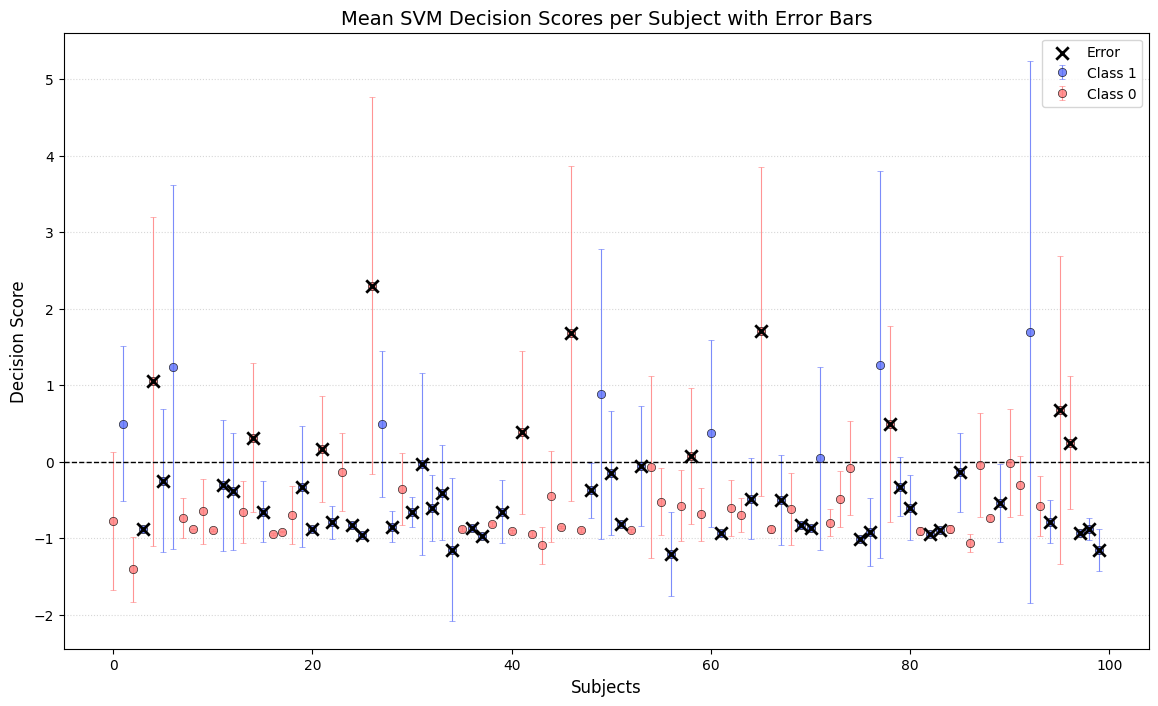

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- 1. SETUP ---
# (Using X and y from your TCGA/Genetic merge)
# If using StratifiedKFold, each subject is tested once.
# To get 'error bars' or 'means' like the image, we can use RepeatedStratifiedKFold.
from sklearn.model_selection import RepeatedStratifiedKFold
outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', probability=True))
])

param_grid = {'svm__C': [0.001, 0.01, 0.1, 1, 10]}

# Dictionary to store multiple scores per subject index
subject_scores = {i: [] for i in range(len(X))}

print("Generating subject-wise decision scores...")

# --- 2. REPEATED NESTED CV LOOP ---
for train_idx, test_idx in outer_cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    grid = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring='balanced_accuracy')
    grid.fit(X_train, y_train)

    # Get scores for this fold
    scores = grid.best_estimator_.decision_function(X_test)

    # Store scores back to the original subject indices
    for idx, score in zip(test_idx, scores):
        subject_scores[idx].append(score)

# --- 3. DATA PREPARATION FOR PLOT ---
summary_data = []
for i in range(len(X)):
    mean_score = np.mean(subject_scores[i])
    std_score = np.std(subject_scores[i])
    true_label = y.iloc[i]
    # Error: Predicted positive (score > 0) but true is 0, OR vice versa
    is_error = (mean_score > 0 and true_label == 0) or (mean_score <= 0 and true_label == 1)

    summary_data.append({
        'Subject': i,
        'Mean_Score': mean_score,
        'Std_Score': std_score,
        'Label': 'Class 1' if true_label == 1 else 'Class 0',
        'Is_Error': is_error
    })

pdf = pd.DataFrame(summary_data)

# --- 4. THE SUBJECT-WISE PLOT ---
plt.figure(figsize=(14, 8))

# Define colors based on your reference (Blue for MD, Red for SZ)
colors = {'Class 1': '#5b6ff9', 'Class 0': '#ff7a7a'}

# Plot each class separately
for label in ['Class 1', 'Class 0']:
    subset = pdf[pdf['Label'] == label]
    plt.errorbar(subset['Subject'], subset['Mean_Score'], yerr=subset['Std_Score'],
                 fmt='o', color=colors[label], label=label,
                 mec='black', mew=0.5, capsize=2, elinewidth=0.8, alpha=0.8)

# Overlay 'X' markers for errors
errors = pdf[pdf['Is_Error'] == True]
plt.scatter(errors['Subject'], errors['Mean_Score'], marker='x', color='black',
            s=80, linewidths=2, label='Error', zorder=5)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Mean SVM Decision Scores per Subject with Error Bars", fontsize=14)
plt.xlabel("Subjects", fontsize=12)
plt.ylabel("Decision Score", fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.show()

/tmp/ipython-input-1175735488.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_y, palette='Set2')


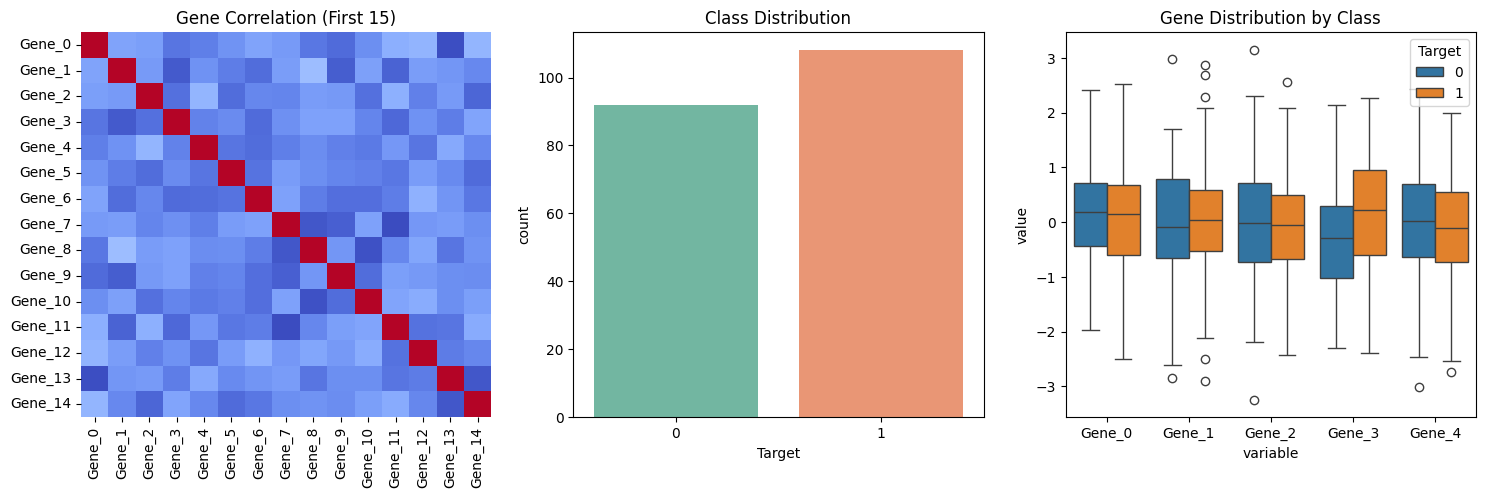

Running 5x5 Nested CV with Permutations...


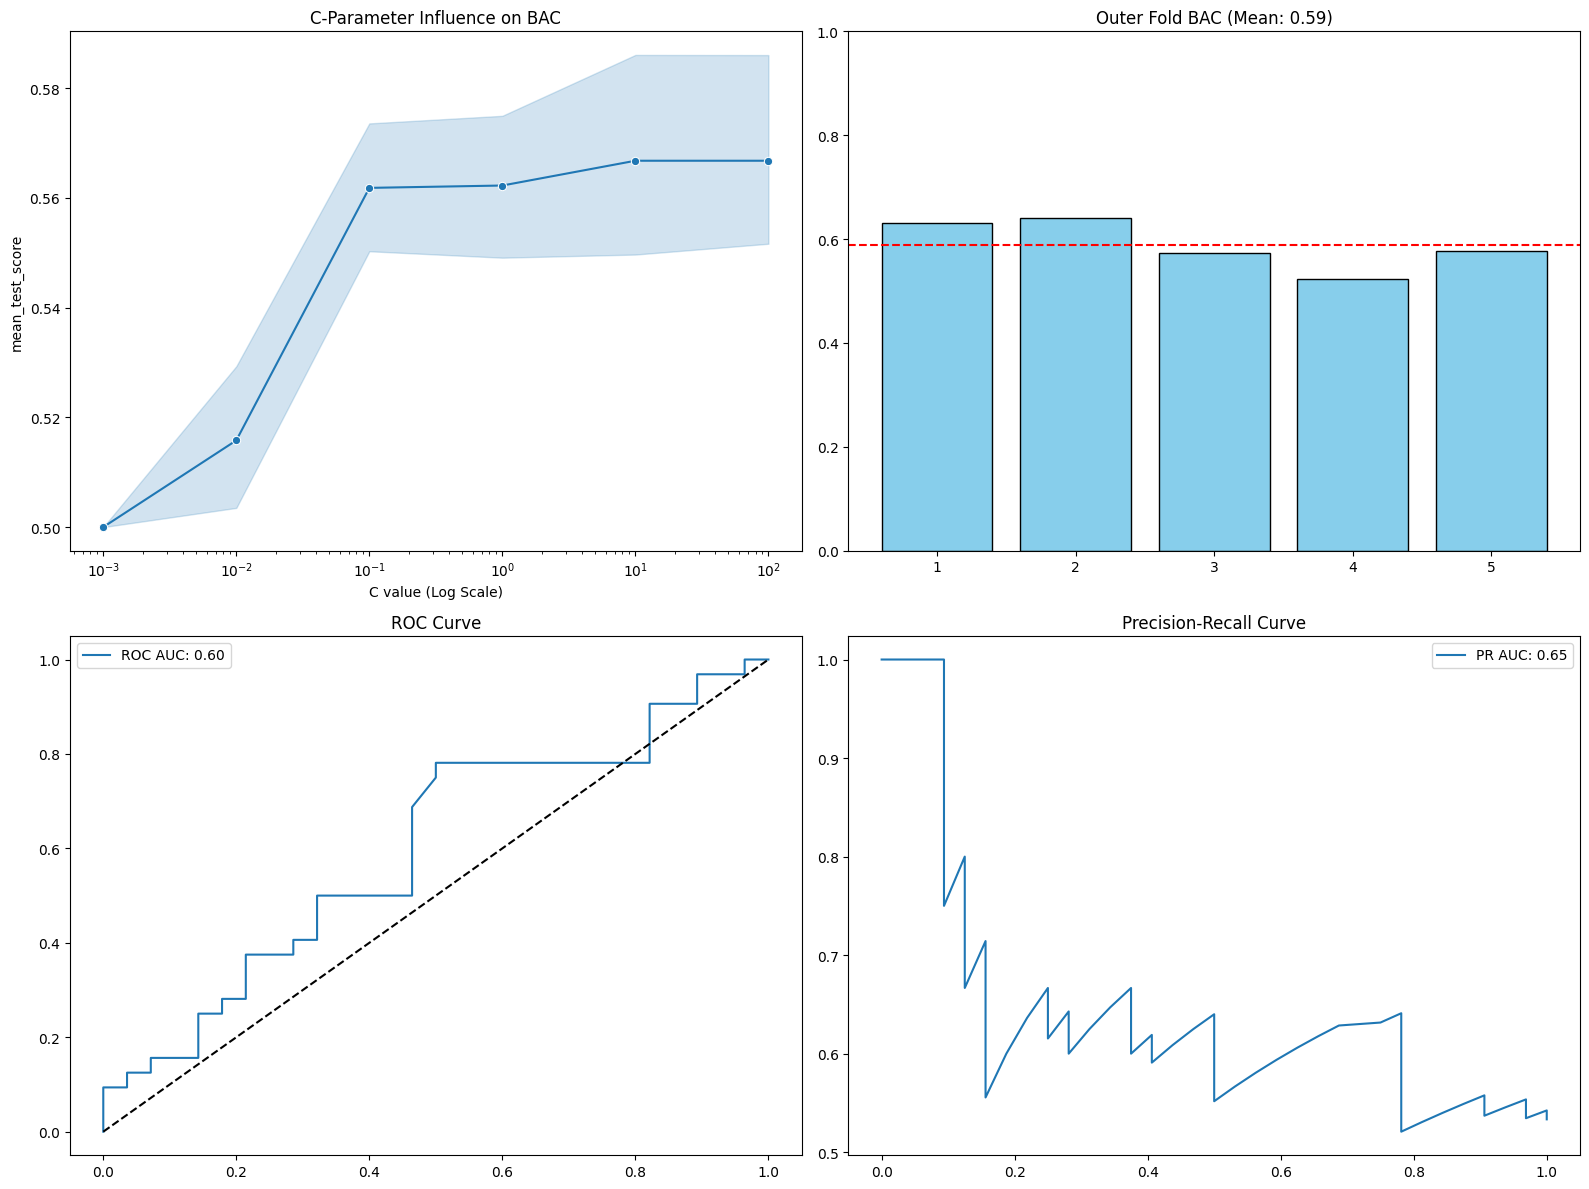


Final Statistics:
Sensitivity (Recall): 0.50
Specificity: 0.57
Permutation p-value: 0.1667


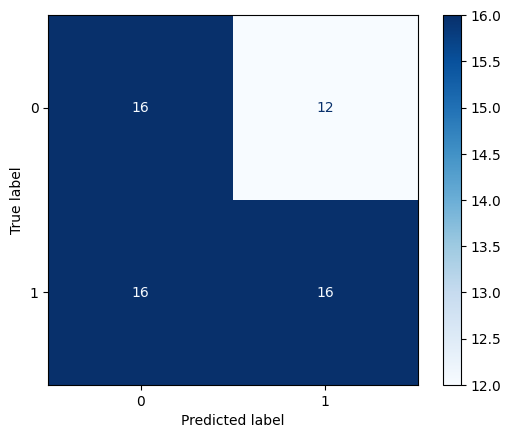

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, permutation_test_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, balanced_accuracy_score, roc_curve,
                             auc, precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.pipeline import Pipeline

# ==========================================
# 1. DATA MERGING & VISUALIZATION (APRIORI)
# ==========================================
# Simulating a TCGA-style merge
np.random.seed(42)
X = pd.DataFrame(np.random.randn(200, 20), columns=[f'Gene_{i}' for i in range(20)])
y = pd.Series(np.random.randint(0, 2, 200), name='Target')

def run_visualizations(df_X, df_y):
    plt.figure(figsize=(18, 5))

    # Feature Correlation Heatmap
    plt.subplot(1, 3, 1)
    sns.heatmap(df_X.iloc[:, :15].corr(), cmap='coolwarm', cbar=False)
    plt.title("Gene Correlation (First 15)")

    # Class Distribution
    plt.subplot(1, 3, 2)
    sns.countplot(x=df_y, palette='Set2')
    plt.title("Class Distribution")

    # Feature Boxplots (First 5 Genes)
    plt.subplot(1, 3, 3)
    data_melt = pd.melt(pd.concat([df_X.iloc[:, :5], df_y], axis=1), id_vars='Target')
    sns.boxplot(data=data_melt, x='variable', y='value', hue='Target')
    plt.title("Gene Distribution by Class")
    plt.show()

run_visualizations(X, y)

# ==========================================
# 2. NESTED CV & PERMUTATION SETUP
# ==========================================
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, kernel='linear'))
])

param_grid = {'svm__C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Tracking variables
outer_bac_scores = []
tuning_results = []
subject_scores = {i: [] for i in range(len(X))}

print("Running 5x5 Nested CV with Permutations...")

# --- OUTER LOOP ---
for i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Inner Loop for C-Parameter Tuning
    grid = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring='balanced_accuracy')
    grid.fit(X_train, y_train)

    # Store tuning influence data
    res = pd.DataFrame(grid.cv_results_)
    res['Outer_Fold'] = i + 1
    tuning_results.append(res)

    # Evaluate on Outer Fold
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    # Store stats
    outer_bac_scores.append(balanced_accuracy_score(y_test, y_pred))

    # Decision scores for the Subject-wise plot
    d_scores = best_model.decision_function(X_test)
    for idx, score in zip(test_idx, d_scores):
        subject_scores[idx].append(score)

# ==========================================
# 3. STATISTICAL VALIDATION (PERMUTATION)
# ==========================================
# Running 5 permutations on the outer layer as requested
score, perm_scores, pvalue = permutation_test_score(
    grid, X, y, scoring="balanced_accuracy", cv=outer_cv, n_permutations=5, n_jobs=-1
)

# ==========================================
# 4. FINAL PLOTS & PERFORMANCE
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot A: Influence of C-parameter
all_tuning = pd.concat(tuning_results)
sns.lineplot(ax=axes[0,0], data=all_tuning, x='param_svm__C', y='mean_test_score', marker='o')
axes[0,0].set_xscale('log')
axes[0,0].set_title("C-Parameter Influence on BAC")
axes[0,0].set_xlabel("C value (Log Scale)")

# Plot B: Balanced Accuracy (BAC) per Outer Fold
axes[0,1].bar(range(1, 6), outer_bac_scores, color='skyblue', edgecolor='black')
axes[0,1].axhline(np.mean(outer_bac_scores), color='red', linestyle='--', label='Mean BAC')
axes[0,1].set_title(f"Outer Fold BAC (Mean: {np.mean(outer_bac_scores):.2f})")
axes[0,1].set_ylim(0, 1)

# Split for Curves
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y)
grid.fit(X_tr, y_tr)
y_probs = grid.predict_proba(X_te)[:, 1]

# Plot C: ROC-AUC
fpr, tpr, _ = roc_curve(y_te, y_probs)
axes[1,0].plot(fpr, tpr, label=f'ROC AUC: {auc(fpr, tpr):.2f}')
axes[1,0].plot([0, 1], [0, 1], 'k--')
axes[1,0].set_title("ROC Curve")
axes[1,0].legend()

# Plot D: PR-AUC
precision, recall, _ = precision_recall_curve(y_te, y_probs)
axes[1,1].plot(recall, precision, label=f'PR AUC: {average_precision_score(y_te, y_probs):.2f}')
axes[1,1].set_title("Precision-Recall Curve")
axes[1,1].legend()

plt.tight_layout()
plt.show()

# --- CONFUSION MATRIX & METRICS ---
cm = confusion_matrix(y_te, grid.predict(X_te))
tn, fp, fn, tp = cm.ravel()
print(f"\nFinal Statistics:")
print(f"Sensitivity (Recall): {tp/(tp+fn):.2f}")
print(f"Specificity: {tn/(tn+fp):.2f}")
print(f"Permutation p-value: {pvalue:.4f}")
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show()